In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import nbinom, binom

Currently, we draw $10^5$ samples at each iteration in generate_samples_from_aligned_spin_template_parameters(). After the first iteration however, we know how many samples we generated and how many survived reweighting and so we can get an estimate of the sampling efficiency. We can then use this estimate to find out (e.g. at the 90% level) how many samples we need to generate initially to reach the requested number of effective samples.

Let's say we draw $n_\mathrm{total}$ samples and $n_\mathrm{eff}$ pass our reweighting stages. This problem is binomial, except we know the total number of trials and number of successes and want to work out the probability of success. It is clear that the best estimator of sampling efficiency here is simply given by

$$
E[S_\mathrm{eff}] = \frac{n_\mathrm{eff}}{n_\mathrm{total}}.
$$

The expectation value of the number of samples required to generate $n_\mathrm{gen}$ to get the required number of effective samples $n_\mathrm{req}$ is then simply

$$
E[n_\mathrm{gen}] = \frac{n_\mathrm{req}}{S_\mathrm{eff}}.
$$

Both of these however have distributions and associated uncertainties. Although estimates of confidence intervals can be found for the first (e.g. [wikipedia](https://en.wikipedia.org/wiki/Binomial_distribution#Confidence_intervals_for_the_parameter_p)), I am unsure on the full distribution.

For the second, it follows the negative binomial distribution.

Working these both out and propagating distributions/uncertainties correctly is not trivial and overkill for our purposes. From quick tests it seems that the uncertainty on the first is likely for low $n_\mathrm{eff}$, and the second for higher $n_\mathrm{eff}$.

In the first case, we can use 

$$
\tilde{S}_\mathrm{eff} = E[S_\mathrm{eff}] - (1-\alpha)\sqrt{\frac{E[S_\mathrm{eff}](1-E[S_\mathrm{eff}])}{n_\mathrm{total}}},
$$

where $\alpha$ is the error rate (i.e. 1 minus the confidence level), and $\tilde{S}_\mathrm{eff}$ is the conservative value of the sampling efficiency that we would plug into the equation above to find $n_\mathrm{gen}$.

In the second case, we would ignore the first error and calculate the uncertainty on the negative binomial distribution to the same confidence level as follows

$$
\tilde{n}_\mathrm{gen} = \mathrm{PPF}(1-\alpha, n_\mathrm{req}, E[S_\mathrm{eff}]).
$$

Both are easy to calculate, and so we can do both simply take the highest number suggested to be on the safe side.

Below are the results for two realistic scenarios.

Method 2 is higher in 9.26% of cases, starting at n_eff = 4537


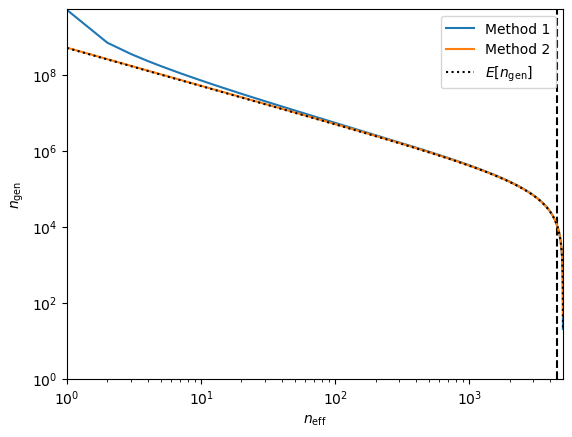

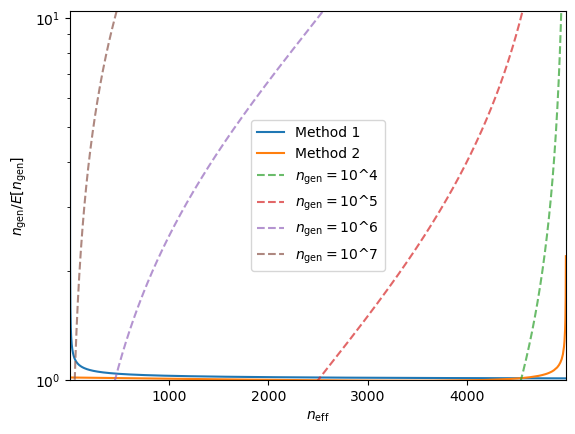

In [117]:
# Choices - after first iteration
alpha = 0.1
n_total = 10**5
n_req = 5000

# Initial calculation
n_eff = np.arange(1, n_req)
n_req = 5000 - n_eff

# Expectation value
expect = n_req*n_total/n_eff

# Method 1
S_eff = n_eff/n_total
S_eff -= (1-alpha)*np.sqrt(S_eff*(1-S_eff)/n_total)
n_gen1 = n_req/S_eff

# Method 2
S_eff = n_eff/n_total
n_gen2 = nbinom.ppf(1-alpha, n_req, S_eff)

# Print comparison
higher_percent = 100*np.sum(n_gen2>n_gen1)/len(n_eff)
print_text = f'Method 2 is higher in {higher_percent:.2f}% of cases'
if higher_percent > 0:
    higher_n_eff = n_eff[n_gen2>n_gen1][0]
    plt.axvline(higher_n_eff, c='k', ls='dashed')
    print_text += ', starting at n_eff = ' +f'{higher_n_eff}'
print(print_text)

# Plot formatting
plt.plot(n_eff, n_gen1, label='Method 1')
plt.plot(n_eff, n_gen2, label='Method 2')
plt.plot(n_eff, expect, label='$E[n_\mathrm{gen}]$', c='k', ls='dotted')
plt.xlabel('$n_\mathrm{eff}$')
plt.ylabel('$n_\mathrm{gen}$')
plt.ylim(1,) 
plt.xlim(np.min(n_eff), np.max(n_eff))
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.show()

# Plot formatting
plt.plot(n_eff, n_gen1/expect, label='Method 1')
plt.plot(n_eff, n_gen2/expect, label='Method 2')
ylim_upper = plt.gca().get_ylim()[1]
for i in range(4, 8):
    plt.plot(n_eff, 10**i/expect, label='$n_\mathrm{gen} = $'+f'10^{i}', ls='dashed', alpha=0.7)
plt.xlabel('$n_\mathrm{eff}$')
plt.ylabel('$n_\mathrm{gen}/E[n_\mathrm{gen}]$')
plt.ylim(1, ylim_upper) 
plt.xlim(np.min(n_eff), np.max(n_eff))
plt.legend()
# plt.xscale('log')
plt.yscale('log')
plt.show()

Method 2 is higher in 100.00% of cases, starting at n_eff = 4500


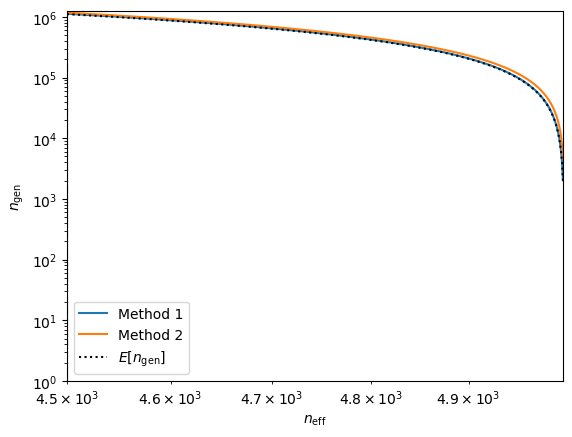

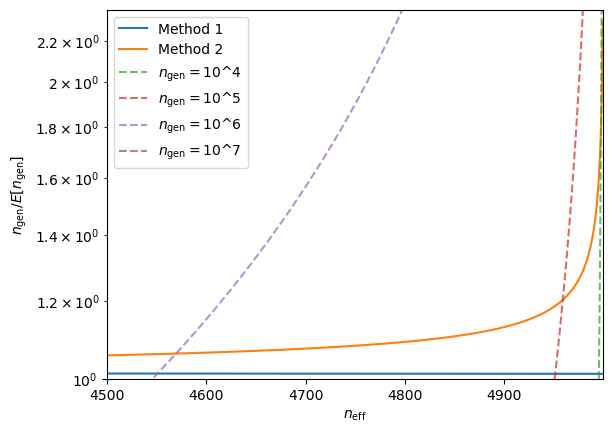

In [118]:
# Choices - after second iteration, should be close to complete
alpha = 0.1
n_total = 10**7
n_req = 5000

# Initial calculation
n_eff = np.arange(4500, n_req)
n_req = 5000 - n_eff

# Expectation value
expect = n_req*n_total/n_eff

# Method 1
S_eff = n_eff/n_total
S_eff -= (1-alpha)*np.sqrt(S_eff*(1-S_eff)/n_total)
n_gen1 = n_req/S_eff

# Method 2
S_eff = n_eff/n_total
n_gen2 = nbinom.ppf(1-alpha, n_req, S_eff)

# Print comparison
higher_percent = 100*np.sum(n_gen2>n_gen1)/len(n_eff)
print_text = f'Method 2 is higher in {higher_percent:.2f}% of cases'
if higher_percent > 0:
    higher_n_eff = n_eff[n_gen2>n_gen1][0]
    plt.axvline(higher_n_eff, c='k', ls='dashed')
    print_text += ', starting at n_eff = ' +f'{higher_n_eff}'
print(print_text)

# Plot formatting
plt.plot(n_eff, n_gen1, label='Method 1')
plt.plot(n_eff, n_gen2, label='Method 2')
plt.plot(n_eff, expect, label='$E[n_\mathrm{gen}]$', c='k', ls='dotted')
plt.xlabel('$n_\mathrm{eff}$')
plt.ylabel('$n_\mathrm{gen}$')
plt.ylim(1,) 
plt.xlim(np.min(n_eff), np.max(n_eff))
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.show()

# Plot formatting
plt.plot(n_eff, n_gen1/expect, label='Method 1')
plt.plot(n_eff, n_gen2/expect, label='Method 2')
ylim_upper = plt.gca().get_ylim()[1]
for i in range(4, 8):
    plt.plot(n_eff, 10**i/expect, label='$n_\mathrm{gen} = $'+f'10^{i}', ls='dashed', alpha=0.7)
plt.xlabel('$n_\mathrm{eff}$')
plt.ylabel('$n_\mathrm{gen}/E[n_\mathrm{gen}]$')
plt.ylim(1, ylim_upper) 
plt.xlim(np.min(n_eff), np.max(n_eff))
plt.legend()
# plt.xscale('log')
plt.yscale('log')
plt.show()

See that both methods can be useful in different regimes.

Can now simulate tests to make sure it works without excessive sample generation or iteration.

In [220]:
def test_method(method, S_eff_true, n_total_init, n_req, n_sims, alpha):

    assert method in ['expect', 'method_1', 'method_2', 'max', 'quad']

    # Loop until meet requirement
    n_eff = np.zeros(n_sims)
    n_it = np.zeros(n_sims)
    n_gen = np.ones(n_sims, dtype=int)*n_total_init
    n_total = np.zeros(n_sims)
    inds = n_eff < n_req
    while np.sum(n_eff < n_req):
        n_it[inds] += 1

        # Simulate rejection iteration
        n_eff[inds] += binom.rvs(n_gen[inds], S_eff_true)
        n_eff[n_eff<1] = np.ones(np.sum(n_eff<1))
        if np.sum(n_eff<1) > 0:
            print(method, np.max(n_it), len(inds), n_eff[n_eff<1])
        n_total[inds] += n_gen[inds]
        inds = n_eff < n_req
        n_req_it = n_req - n_eff[inds]

        # Calculate simple expectation value
        if method in ['expect', 'quad']:
            expect = n_req_it*n_total[inds]/n_eff[inds]

        # Calculate method 1
        if method in ['method_1', 'max', 'quad']:
            S_eff = n_eff[inds]/n_total[inds]
            S_eff -= (1-alpha)*np.sqrt(S_eff*(1-S_eff)/n_total[inds])
            n_gen1 = n_req_it/S_eff

        # Calculate method 2
        if method in ['method_2', 'max', 'quad']:
            S_eff = n_eff[inds]/n_total[inds]
            n_gen2 = nbinom.ppf(1-alpha, n_req_it, S_eff)

        # Update based on method
        match method:
            case 'expect':
                n_gen[inds] = expect
            case 'method_1':
                n_gen[inds] = n_gen1
            case 'method_2':
                n_gen[inds] = n_gen2
            case 'max':
                n_gen[inds] = np.maximum(n_gen1, n_gen2)
            case 'quad':
                err1 = n_gen1 - expect
                err2 = n_gen2 - expect
                n_gen[inds] = expect + np.sqrt(err1**2 + err2**2)
        n_gen[inds] = np.round(n_gen[inds])

    return n_it, n_total, n_eff

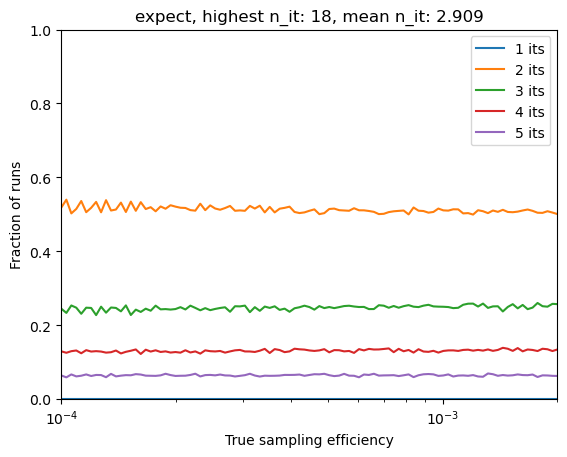

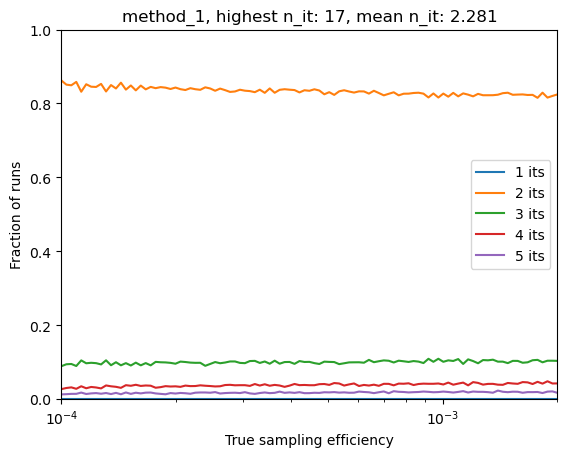

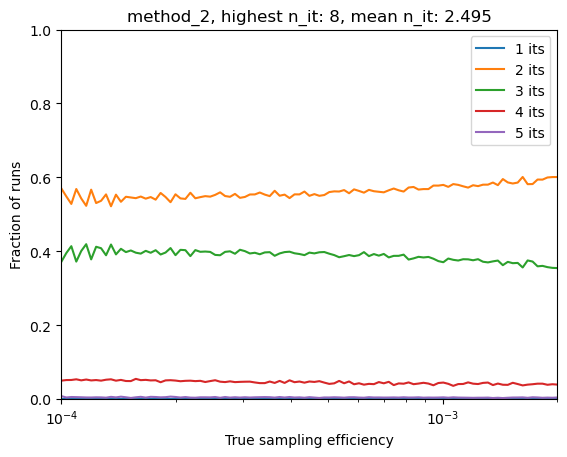

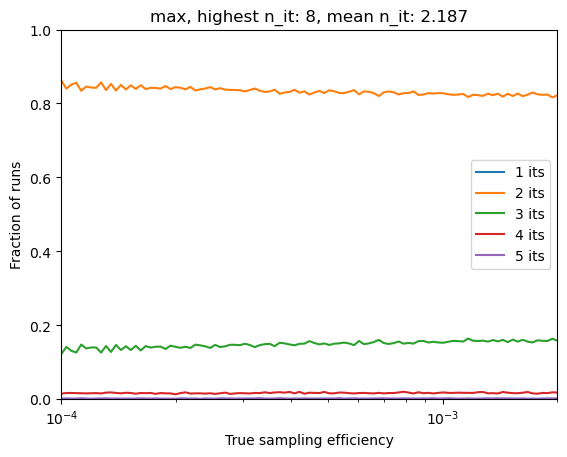

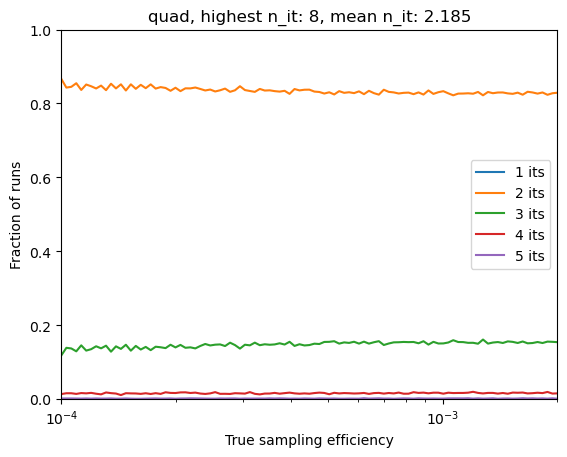

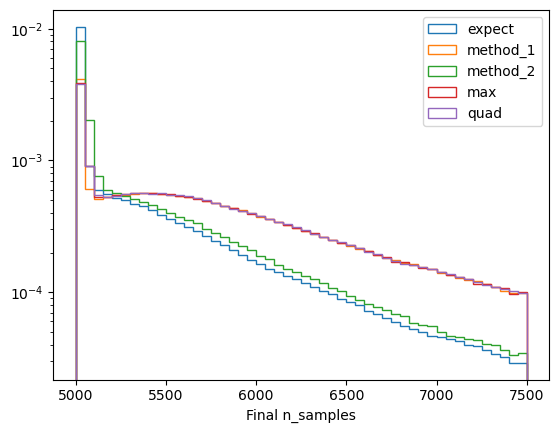

In [221]:
n_total_init = 10**5
n_req = 5000
n_sims = 10**4
alpha = 0.1
S_effs = np.geomspace(10/n_total_init, 200/n_total_init, 101)

method_n_effs = []
for method in ['expect', 'method_1', 'method_2', 'max', 'quad']:

    n_its = []
    n_totals = []
    n_effs = []
    plot_counts = 5
    n_counts = []
    for i, S_eff in enumerate(S_effs):
        n_it, n_total, n_eff = test_method(method, S_eff, n_total_init, n_req, n_sims, alpha)
        n_its.append(n_it)
        n_totals.append(n_total)
        n_effs.append(n_eff)
        n_counts.append([])
        for j in range(1, plot_counts+1):
            n_counts[-1].append(np.count_nonzero(n_it==j))
    n_counts = np.array(n_counts).T
    method_n_effs.append(n_effs)
    
    for i in range(plot_counts):
        plt.plot(S_effs, n_counts[i]/n_sims, label=f'{i+1} its')
    plt.xscale('log')
    plt.ylim(0, 1)
    plt.xlim(np.min(S_effs), np.max(S_effs))
    plt.xlabel('True sampling efficiency')
    plt.ylabel('Fraction of runs')
    plt.title(f'{method}, highest n_it: {int(np.max(n_its))}, mean n_it: {np.mean(n_its):.3f}')
    plt.legend()
    plt.show()

for i, method in enumerate(['expect', 'method_1', 'method_2', 'max', 'quad']):
    plt.hist(np.array(method_n_effs[i]).flatten(), range=(n_req, n_req*1.5), bins=50, histtype='step', density=True, label=method)
plt.legend()
plt.xlabel('Final n_samples')
plt.yscale('log')
plt.show()

Either max or quadrature method seems best, despite it producing the most samples. Because it takes both errors into account it can reduce the number of iterations both when starting from a low number of effective samples after the first iteration, and when close to the required number of samples after subsequent iterations.

In theory quadrature should be better near 'cross over' point where method_1 and method_2 have similar errors. This is very hard to reach though, requiring either quite a high sampling efficiency or an unlikely low number of samples after the second iteration. Nevertheless will choose to use the quadrature method.

We must now also take into account any memory issues associated with generating large arrays of samples.

In [208]:
import time

for i in range(9):
    n = 10**i
    start = time.time()
    for j in range(10):
        arr = np.random.uniform(0, 1, n)
    end = time.time()
    size_bytes = arr.itemsize*arr.size
    size_mb = size_bytes / (1024**2)
    print(f'array with 10^{i} samples is {size_mb:.2f} megabytes, time = {(end-start)/10} seconds')

array with 10^0 samples is 0.00 megabytes, time = 0.0019760370254516602 seconds
array with 10^1 samples is 0.00 megabytes, time = 9.894371032714844e-06 seconds
array with 10^2 samples is 0.00 megabytes, time = 7.081031799316406e-06 seconds
array with 10^3 samples is 0.01 megabytes, time = 3.3783912658691404e-05 seconds
array with 10^4 samples is 0.08 megabytes, time = 8.072853088378907e-05 seconds
array with 10^5 samples is 0.76 megabytes, time = 0.0007766962051391601 seconds
array with 10^6 samples is 7.63 megabytes, time = 0.008442354202270509 seconds
array with 10^7 samples is 76.29 megabytes, time = 0.08470115661621094 seconds
array with 10^8 samples is 762.94 megabytes, time = 0.8171683073043823 seconds


In [216]:
def test_method(method, S_eff_true, n_total_init, n_req, n_sims, alpha):

    assert method in ['expect', 'method_1', 'method_2', 'max', 'quad']

    # Loop until meet requirement
    n_eff = np.zeros(n_sims)
    n_it = np.zeros(n_sims)
    n_gen = np.ones(n_sims, dtype=int)*n_total_init
    n_total = np.zeros(n_sims)
    inds = n_eff < n_req
    while np.sum(n_eff < n_req):
        n_it[inds] += 1

        # Simulate rejection iteration
        n_eff[inds] += binom.rvs(n_gen[inds], S_eff_true)
        n_eff[n_eff<1] = np.ones(np.sum(n_eff<1))
        if np.sum(n_eff<1) > 0:
            print(method, np.max(n_it), len(inds), n_eff[n_eff<1])
        n_total[inds] += n_gen[inds]
        inds = n_eff < n_req
        n_req_it = n_req - n_eff[inds]

        # Calculate simple expectation value
        if method in ['expect', 'quad']:
            expect = n_req_it*n_total[inds]/n_eff[inds]

        # Calculate method 1
        if method in ['method_1', 'max', 'quad']:
            S_eff = n_eff[inds]/n_total[inds]
            S_eff -= (1-alpha)*np.sqrt(S_eff*(1-S_eff)/n_total[inds])
            n_gen1 = n_req_it/S_eff

        # Calculate method 2
        if method in ['method_2', 'max', 'quad']:
            S_eff = n_eff[inds]/n_total[inds]
            n_gen2 = nbinom.ppf(1-alpha, n_req_it, S_eff)

        # Update based on method
        match method:
            case 'expect':
                n_gen[inds] = expect
            case 'method_1':
                n_gen[inds] = n_gen1
            case 'method_2':
                n_gen[inds] = n_gen2
            case 'max':
                n_gen[inds] = np.maximum(n_gen1, n_gen2)
            case 'quad':
                err1 = n_gen1 - expect
                err2 = n_gen2 - expect
                n_gen[inds] = expect + np.sqrt(err1**2 + err2**2)
        n_gen[inds] = np.round(n_gen[inds])
        n_gen[inds] = np.minimum(n_gen[inds], np.ones(len(n_gen[inds]))*10**7)

    return n_it, n_total, n_eff

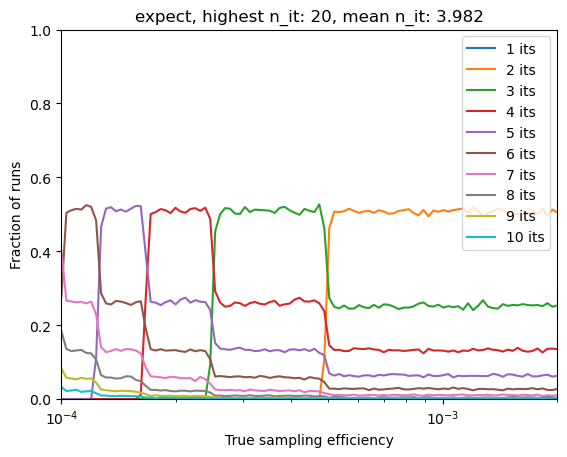

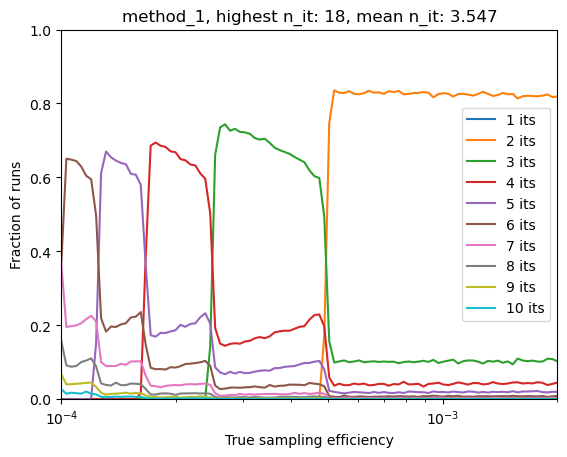

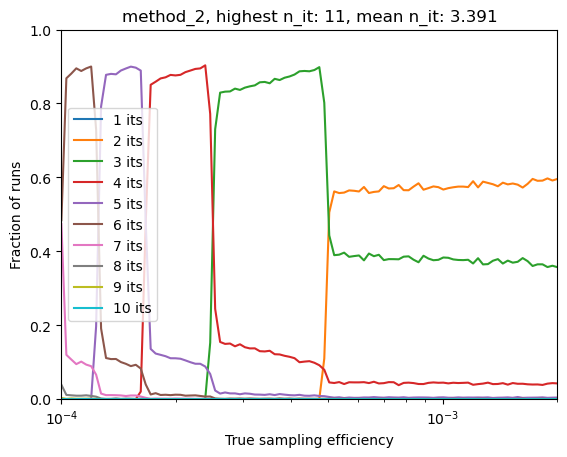

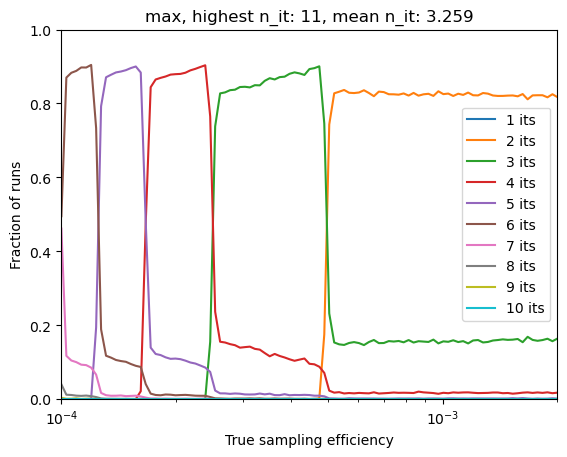

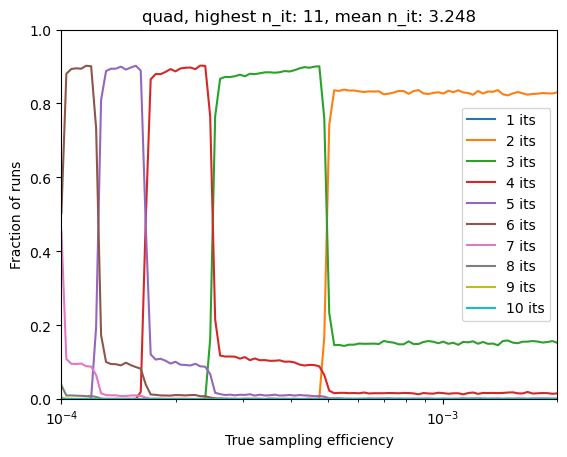

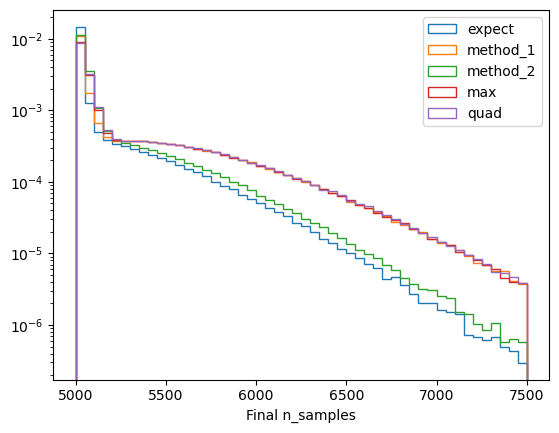

In [217]:
n_total_init = 10**5
n_req = 5000
n_sims = 10**4
alpha = 0.1
S_effs = np.geomspace(10/n_total_init, 200/n_total_init, 101)

method_n_effs = []
for method in ['expect', 'method_1', 'method_2', 'max', 'quad']:

    n_its = []
    n_totals = []
    n_effs = []
    plot_counts = 10
    n_counts = []
    for i, S_eff in enumerate(S_effs):
        n_it, n_total, n_eff = test_method(method, S_eff, n_total_init, n_req, n_sims, alpha)
        n_its.append(n_it)
        n_totals.append(n_total)
        n_effs.append(n_eff)
        n_counts.append([])
        for j in range(1, plot_counts+1):
            n_counts[-1].append(np.count_nonzero(n_it==j))
    n_counts = np.array(n_counts).T
    method_n_effs.append(n_effs)
    
    for i in range(plot_counts):
        plt.plot(S_effs, n_counts[i]/n_sims, label=f'{i+1} its')
    plt.xscale('log')
    plt.ylim(0, 1)
    plt.xlim(np.min(S_effs), np.max(S_effs))
    plt.xlabel('True sampling efficiency')
    plt.ylabel('Fraction of runs')
    plt.title(f'{method}, highest n_it: {int(np.max(n_its))}, mean n_it: {np.mean(n_its):.3f}')
    plt.legend()
    plt.show()

for i, method in enumerate(['expect', 'method_1', 'method_2', 'max', 'quad']):
    plt.hist(np.array(method_n_effs[i]).flatten(), range=(n_req, n_req*1.5), bins=50, histtype='step', density=True, label=method)
plt.legend()
plt.xlabel('Final n_samples')
plt.yscale('log')
plt.show()

Using a limit of $10^7$ seems sensible.

# Testing scraps

In [10]:
n, p = 17, 0.0017
lb, ub = nbinom.support(n, p)
print(lb, ub)

0 inf


158.27541429303363 181.72458570696637


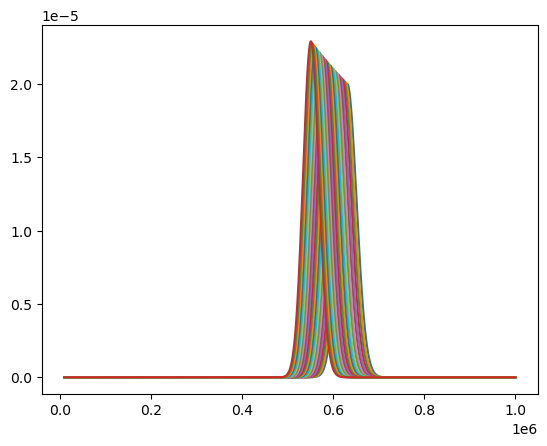

In [46]:
n_gens = np.arange(10000, 1000000, 100)
n_req = 1000

success = 170
sampling_eff_est = success/10**5
alpha = 0.1 # One sided confidence level
z = 1-alpha
success_low = 10**5*(sampling_eff_est - z*np.sqrt(sampling_eff_est*(1-sampling_eff_est)/10**5))
success_high = 10**5*(sampling_eff_est + z*np.sqrt(sampling_eff_est*(1-sampling_eff_est)/10**5))
print(success_low, success_high)
for i in np.arange(success_low, success_high, 1)/10**5:
    prob = nbinom.pmf(n_gens-n_req, n_req, i)
    plt.plot(n_gens, prob)

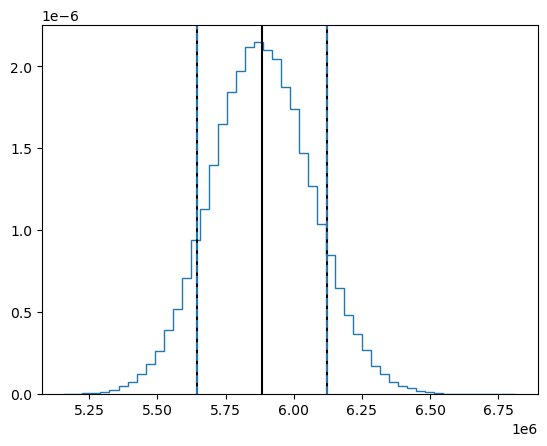

In [53]:
n_req = 10**3
n_total = 10**5
n_eff = 17
S_eff = n_eff/n_total
alpha = 0.1

random_nbinom = nbinom.rvs(n_req, S_eff, size=10**5)
quants = np.quantile(random_nbinom, [0.1, 0.9])
_ = plt.hist(random_nbinom, bins=50, histtype='step', density=True)
predict_quants = [nbinom.ppf(alpha, n_req, S_eff), nbinom.ppf(1-alpha, n_req, S_eff)]
for q in predict_quants:
    plt.axvline(q, c='k')
plt.axvline(n_req/S_eff, c='k')
for q in quants:
    plt.axvline(q, c='C0', ls='dashed')